# Data Collection For Image Processing

**Activity:** Food dishes & ingredients 

**Domain:** Retail / nutrition

**Description:** Photograph dishes, single ingredients, add cuisine labels

**Suggested web sources:** Food-101, Recipe websites (public images)

### Step 1: Load Dataset Structure

In [8]:
import kagglehub
import os
import pandas as pd

# Download dataset (run once)
path = kagglehub.dataset_download("kmader/food41")
print(f"Dataset at: {path}")

# Build DataFrame from images (no CSV exists by default)
image_dir = os.path.join(path, "images")
image_paths = []
labels = []

for label in os.listdir(image_dir):
    label_dir = os.path.join(image_dir, label)
    if os.path.isdir(label_dir):
        for img_file in os.listdir(label_dir)[:5]:  # Limit to 5 per class
            image_paths.append(os.path.join(label_dir, img_file))
            labels.append(label)

df = pd.DataFrame({'image_path': image_paths, 'label': labels})
print("First 5 records:\n", df.head())


100%|██████████| 5.30G/5.30G [06:21<00:00, 14.9MB/s]  

Extracting files...


Dataset at: /home/ubuntu/.cache/kagglehub/datasets/kmader/food41/versions/5
First 5 records:
                                           image_path           label
0  /home/ubuntu/.cache/kagglehub/datasets/kmader/...  fish_and_chips
1  /home/ubuntu/.cache/kagglehub/datasets/kmader/...  fish_and_chips
2  /home/ubuntu/.cache/kagglehub/datasets/kmader/...  fish_and_chips
3  /home/ubuntu/.cache/kagglehub/datasets/kmader/...  fish_and_chips
4  /home/ubuntu/.cache/kagglehub/datasets/kmader/...  fish_and_chips


### Step 2: Visualize images by label

/tmp/ipykernel_9984/3360536425.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples = df.groupby('label').apply(lambda x: random.choice(x.index)).head(10)


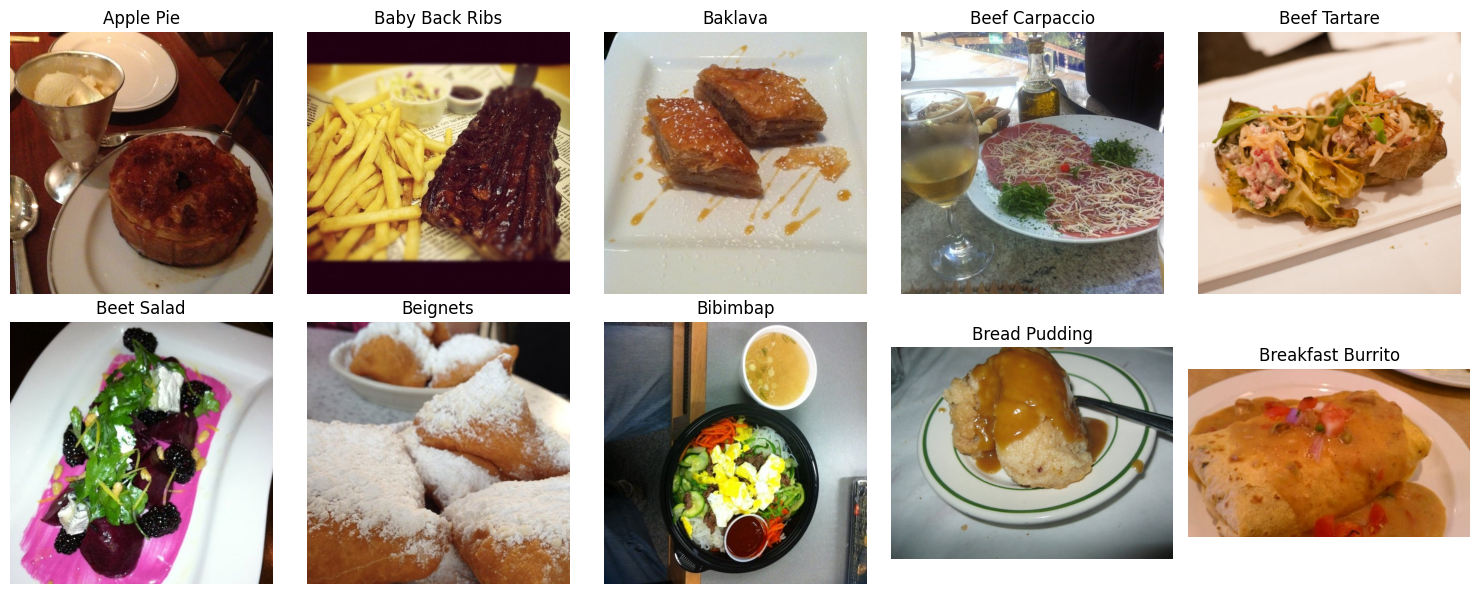

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Sample one image per label for visualization
samples = df.groupby('label').apply(lambda x: random.choice(x.index)).head(10)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for idx, sample_idx in enumerate(samples):
    img_path = df.loc[sample_idx, 'image_path']
    label = df.loc[sample_idx, 'label']
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(label.replace('_', ' ').title())
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


### Select and Copy 200 Random Images

In [11]:
import os
import pandas as pd
import random
import shutil
from pathlib import Path

# Assuming dataset is already downloaded
dataset_path = kagglehub.dataset_download("kmader/food41")
image_dir = os.path.join(dataset_path, "images")

# Create sample directory
sample_dir = Path("./food101_sample")
sample_dir.mkdir(exist_ok=True)

# Collect all image paths with labels
all_images = []
for label in os.listdir(image_dir):
    label_dir = os.path.join(image_dir, label)
    if os.path.isdir(label_dir):
        for img_file in os.listdir(label_dir):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_images.append({
                    'path': os.path.join(label_dir, img_file),
                    'label': label,
                    'filename': img_file
                })

print(f"Total images found: {len(all_images)}")

# Randomly select 200 images (stratified by label)
random.seed(42)  # Reproducible
selected_images = []
seen_labels = set()

# First ensure minimum representation across labels
for label in random.sample(list(set(img['label'] for img in all_images)), min(41, 200)):
    label_images = [img for img in all_images if img['label'] == label]
    selected = random.choice(label_images)
    selected_images.append(selected)
    seen_labels.add(label)

# Fill remaining slots randomly
remaining = 200 - len(selected_images)
if remaining > 0:
    unselected = [img for img in all_images if img['label'] not in seen_labels]
    selected_images.extend(random.sample(unselected, min(remaining, len(unselected))))

df_sample = pd.DataFrame(selected_images)
print(f"Selected {len(df_sample)} images across {df_sample['label'].nunique()} labels")

# Copy images to sample directory (preserve folder structure)
for _, row in df_sample.iterrows():
    src = row['path']
    label_dir = sample_dir / row['label']
    label_dir.mkdir(exist_ok=True)
    dst = label_dir / row['filename']
    shutil.copy2(src, dst)

df_sample.to_csv(sample_dir / "image_inventory.csv", index=False)
print("✅ 200 images copied to ./food101_sample/")


Total images found: 101000
Selected 200 images across 97 labels
✅ 200 images copied to ./food101_sample/
